# CA2 – Problem Solving for Industry
## Notebook 1: Customer Churn Prediction — Approach with SMOTE
### BSc (Hons) in Computing in IT | CCT College Dublin

**Module:** Problem Solving for Industry
**Framework:** CRISP-DM
**Dataset:** Telco Customer Churn – IBM
**Approach for Class Imbalance:** SMOTE (Synthetic Minority Over-sampling Technique)

> **Note:** This notebook uses SMOTE to address the problem of imbalanced classes (only 26.5% of customers churned). SMOTE creates synthetic examples of the minority class (Churn=Yes) in the training set, balancing the classes before training the models.

---


---
## Phase 1 – Business Understanding

### 1.1 Problem Context

**Customer Churn** is one of the biggest challenges in the telecommunications sector. Studies show that acquiring a new customer costs between 5 to 7 times more than retaining an existing customer (Reichheld & Schefter, 2000).

In this project, we work with data from a fictional telecommunications company (IBM Telco Dataset) with about 7,000 customers. The company has a churn rate of approximately **26.5%**, which means that 1 in every 4 customers cancels the service.

### 1.2 Business Objective

The main objective is to **predict which customers are at risk of canceling** the service, allowing the retention team to proactively intervene with personalized offers or discounts.

### 1.3 Success Criteria

| Criterion | Target |
|---|---|
| **Recall (Sensitivity)** | ≥ 75% — Identify the majority of churners |
| **F1-Score** | ≥ 0.70 — Balance between Precision and Recall |
| **Interpretability** | Identify the top 5 churn factors |

### 1.4 Applied CRISP-DM Phases

| Phase | Description |
|---|---|
| 1. Business Understanding | Define the problem and success criteria |
| 2. Data Understanding | Explore and describe the dataset |
| 3. Data Preparation | Clean, encode, and prepare the features |
| 4. Modelling | Train ML classification models |
| 5. Evaluation | Evaluate and compare the models |
| 6. Deployment | Save the model and present recommendations |


## Phase 2 – Data Understanding

### 2.1 About the Dataset

The **IBM Telco Customer Churn** dataset contains **7,043 records** and **21 columns**. Each row represents a unique customer with their demographic characteristics, subscribed services, and whether they churned or not.

**Source:** [Kaggle – Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [1]:
# 
# DEPENDENCY INSTALLATION
# Run this cell FIRST before any other.
# Installs the necessary packages if they are not present in the environment.
# 

import subprocess, sys

def install(package):
    """Installs a package via pip if it is not already installed."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# List of packages required for this project
required_packages = [
    "xgboost",           # XGBoost algorithm (Extreme Gradient Boosting)
    "imbalanced-learn",  # Library with SMOTE (only needed in Notebook 1)
    "scikit-learn",      # ML algorithms, metrics and preprocessing
    "pandas",            # Data manipulation in DataFrames
    "numpy",             # Mathematical operations and arrays
    "matplotlib",        # Basic graphical visualizations
    "seaborn",           # Advanced statistical visualizations
    "joblib",            # Save and load trained models
]

print("Checking and installing dependencies...")
for pkg in required_packages:
    try:
        __import__(pkg.replace("-", "_").split("[")[0])
        print(f"  ✓ {pkg} already installed")
    except ImportError:
        print(f"  ↓ Installing {pkg}...")
        install(pkg)
        print(f"  ✓ {pkg} installed successfully")

print()
print("All dependencies are ready! You can proceed to the next cell.")

Checking and installing dependencies...
  ✓ xgboost already installed
  ↓ Installing imbalanced-learn...
  ✓ imbalanced-learn installed successfully
  ↓ Installing scikit-learn...
  ✓ scikit-learn installed successfully
  ✓ pandas already installed
  ✓ numpy already installed
  ✓ matplotlib already installed
  ✓ seaborn already installed
  ✓ joblib already installed

All dependencies are ready! You can proceed to the next cell.


In [2]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 1: Library Import
# 

# pandas: main library for data manipulation in tables (DataFrames)
import pandas as pd

# numpy: library for mathematical operations and numerical arrays
import numpy as np

# matplotlib.pyplot: base library to create charts and visualizations
import matplotlib.pyplot as plt

# seaborn: high-level visualization library built on matplotlib
# Produces more elegant statistical charts with less code
import seaborn as sns

# warnings: module to suppress unnecessary warnings during execution
import warnings
warnings.filterwarnings('ignore')  # Ignores all warnings for cleaner output

# Visual style configuration for charts
# 'whitegrid' = white background with grid; 'Set2' = soft color palette
sns.set_theme(style='whitegrid', palette='Set2')

# dpi=120 increases chart resolution for better visual quality
plt.rcParams['figure.dpi'] = 120

# Sets the default font for all charts
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 2: Dataset Loading
# 

# pd.read_csv() reads a CSV file and converts it into a pandas DataFrame
# The path '../data/' indicates that the file is in the 'data' folder, one level up
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

# Prints the dimensions of the dataset: (number of rows, number of columns)
print(f"Dataset dimensions: {df.shape}")
# Prints the names of all available columns
print(f"Columns: {list(df.columns)}")

# df.head() shows the first 5 rows of the dataset
# Useful to get an overview of the data structure
df.head()

Dataset dimensions: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 3: Initial Data Quality Analysis
# 

# df.dtypes shows the data type of each column
# Important to identify columns that need type conversion
print("=== Data Types by Column ===")
print(df.dtypes)

# df.isnull().sum() counts the number of null (NaN) values in each column
# Null values need to be handled before modeling
print("\n=== Null Values by Column ===")
print(df.isnull().sum())

# df.describe() calculates descriptive statistics of numerical columns:
# count, mean, std (standard deviation), min, 25%, 50% (median), 75%, max
print("\n=== Descriptive Statistics (Numerical Columns) ===")
df.describe()

=== Data Types by Column ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Null Values by Column ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


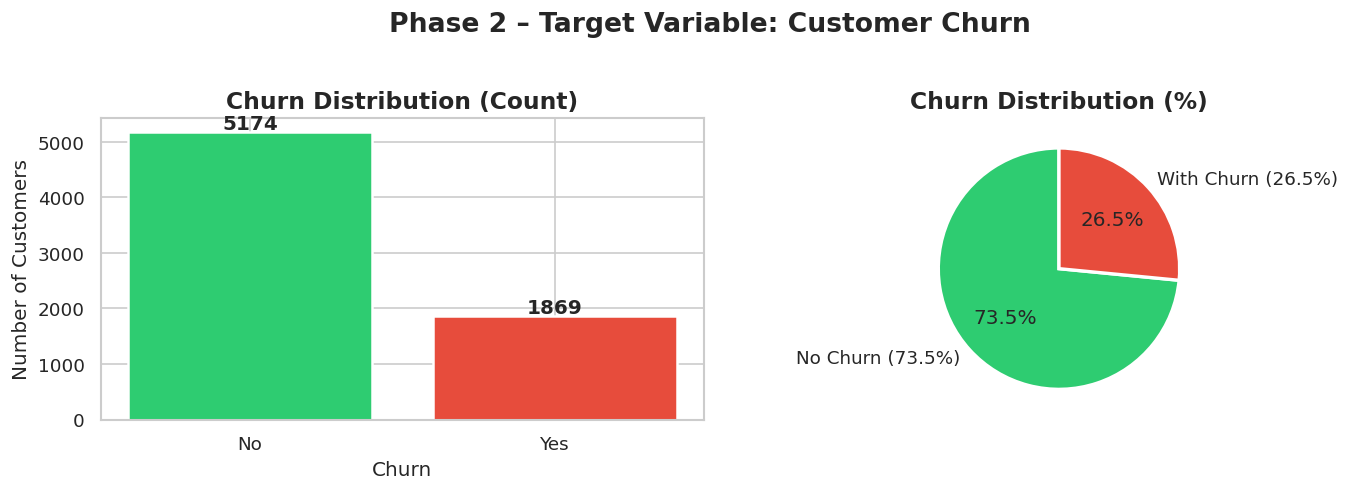

Solution: Use SMOTE in Phase 3 to balance the classes in the training set.


In [5]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 4: Target Variable Distribution (Churn)
# 

# Create a figure with 2 side-by-side subplots
# figsize=(12, 4) sets the width and height of the figure in inches
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count how many customers have Churn='Yes' and Churn='No'
churn_counts = df['Churn'].value_counts()

# --- Bar Chart (left) ---
axes[0].bar(
    churn_counts.index,       # X axis: categories ('No', 'Yes')
    churn_counts.values,      # Y axis: count of each category
    color=['#2ecc71', '#e74c3c'],  # Green for 'No', Red for 'Yes'
    edgecolor='white',        # White border between bars
    linewidth=1.5             # Border thickness
)
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

# Add numeric values on top of each bar
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

# --- Pie Chart (right) ---
axes[1].pie(
    churn_counts.values,
    labels=['No Churn (73.5%)', 'With Churn (26.5%)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',        # Show percentage with 1 decimal place
    startangle=90,            # Start the chart from 12 o'clock
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # White border between slices
)
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Phase 2 – Target Variable: Customer Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
# Save the plot as a PNG file in the images/ folder
plt.savefig('../images/nb1_01_churn_distribution.png', bbox_inches='tight')
plt.show()

# Important conclusion: the dataset is IMBALANCED
# Only 26.5% of customers churned — this is the problem that SMOTE will solve
print("WARNING: IMBALANCED dataset — only 26.5% churners.")
print("Solution: Use SMOTE in Phase 3 to balance the classes in the training set.")

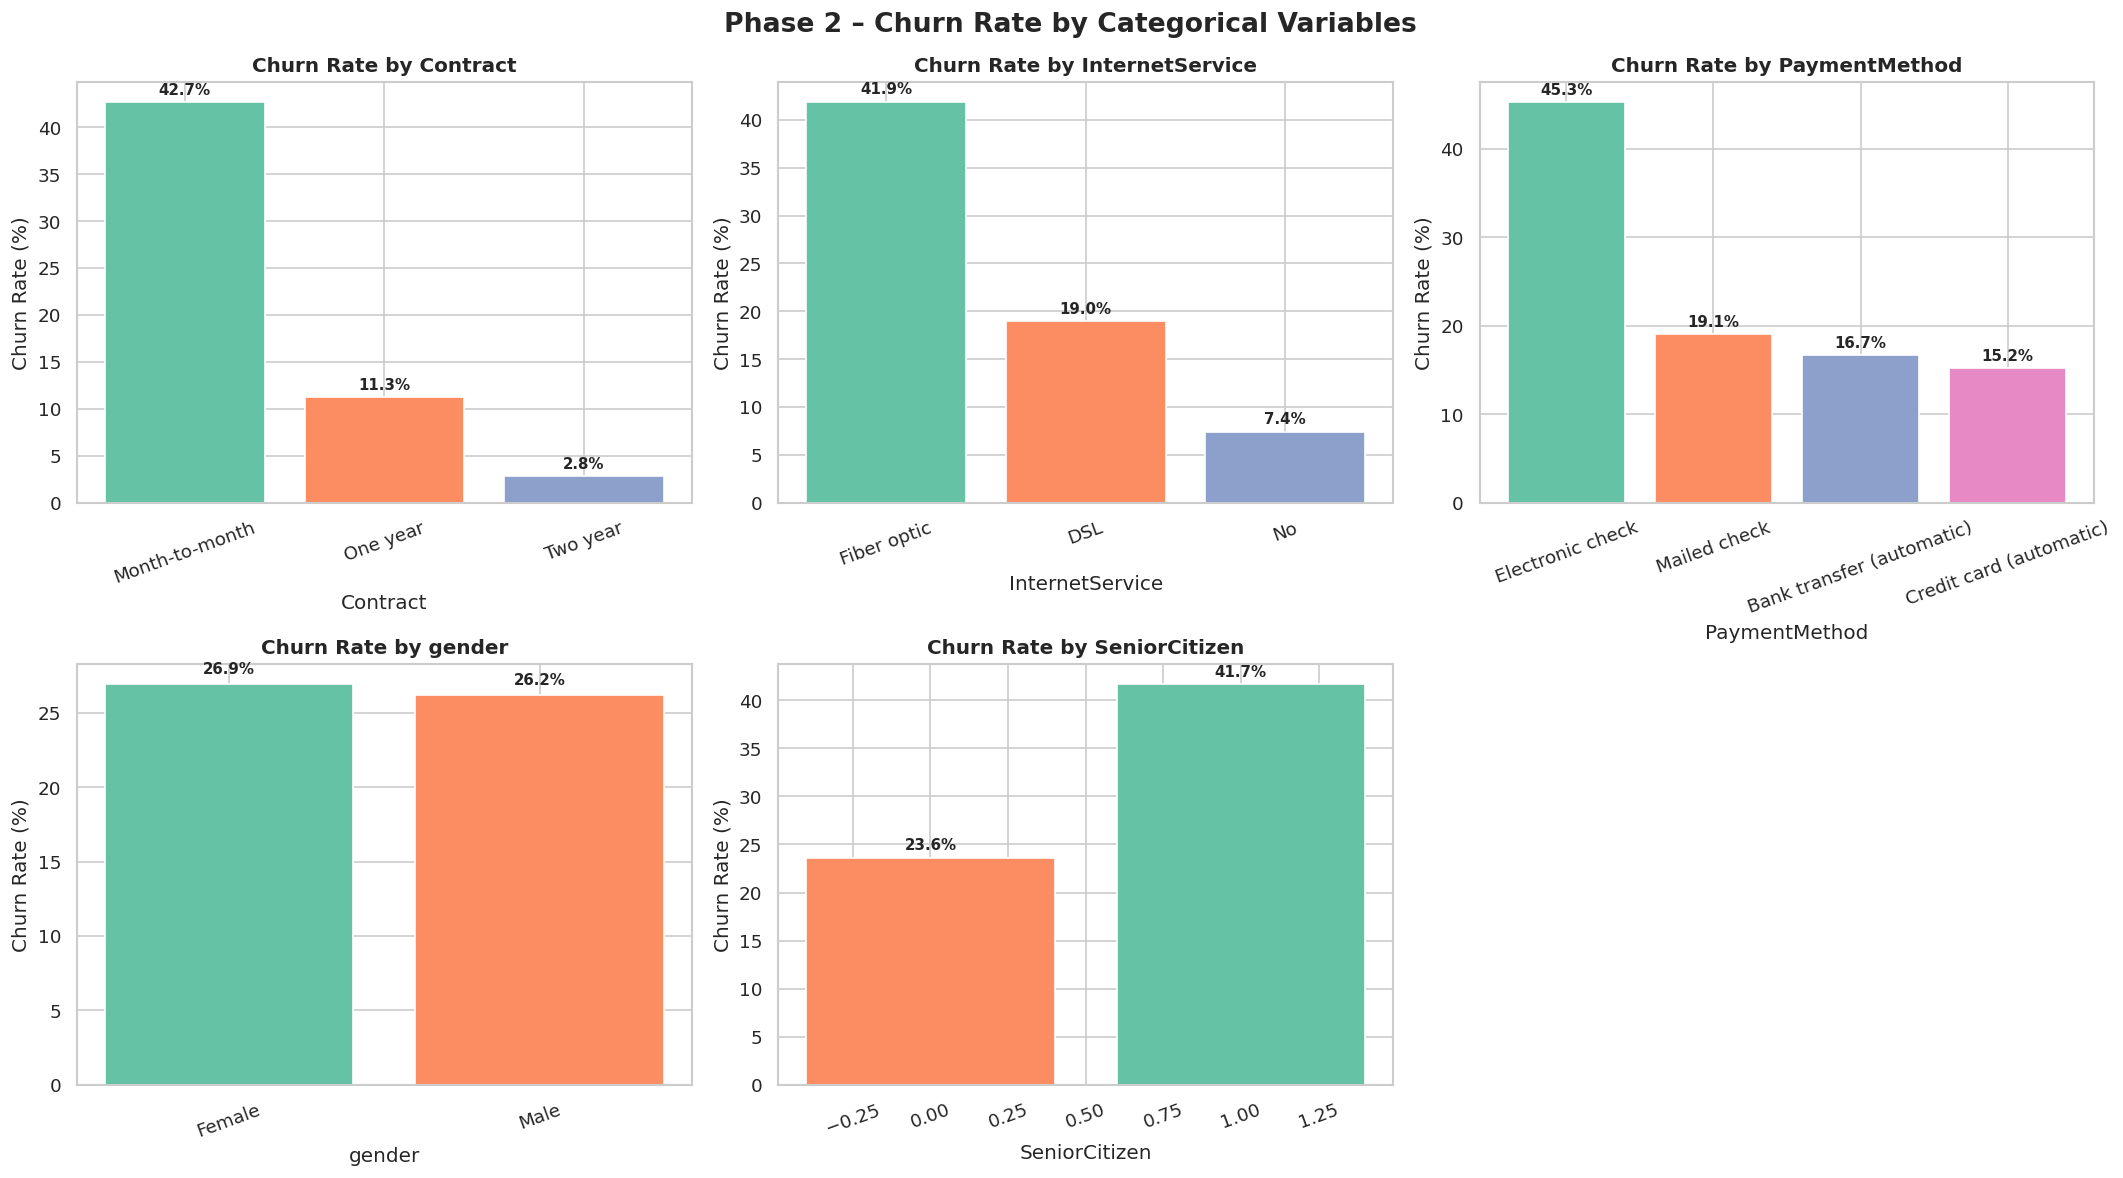

In [6]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 5: Churn Rate by Categorical Variables
# 

# List of the most relevant categorical variables to analyze
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'SeniorCitizen']

# Create a 2 rows x 3 columns grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Convert the 2D matrix of axes into a 1D list for easy iteration

for i, col in enumerate(cat_cols):
    # groupby groups the data by category
    # apply calculates the churn rate (proportion of 'Yes') for each group
    # * 100 converts to percentage
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'Taxa de Churn (%)']
    # Sort from highest to lowest for easier reading
    churn_rate = churn_rate.sort_values('Taxa de Churn (%)', ascending=False)

    # Create bars with different colors for each category
    bars = axes[i].bar(
        churn_rate[col],
        churn_rate['Taxa de Churn (%)'],
        color=sns.color_palette('Set2', len(churn_rate)),
        edgecolor='white'
    )
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=20)  # Rotate X-axis labels to avoid overlap

    # Add the percentage value on top of each bar
    for bar in bars:
        axes[i].text(
            bar.get_x() + bar.get_width()/2.,  # X Position: center of the bar
            bar.get_height() + 0.5,             # Y Position: slightly above the bar
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

# The last subplot remains empty (we have 5 variables but 6 spaces)
axes[-1].set_visible(False)

plt.suptitle('Phase 2 – Churn Rate by Categorical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nb1_02_churn_by_category.png', bbox_inches='tight')
plt.show()

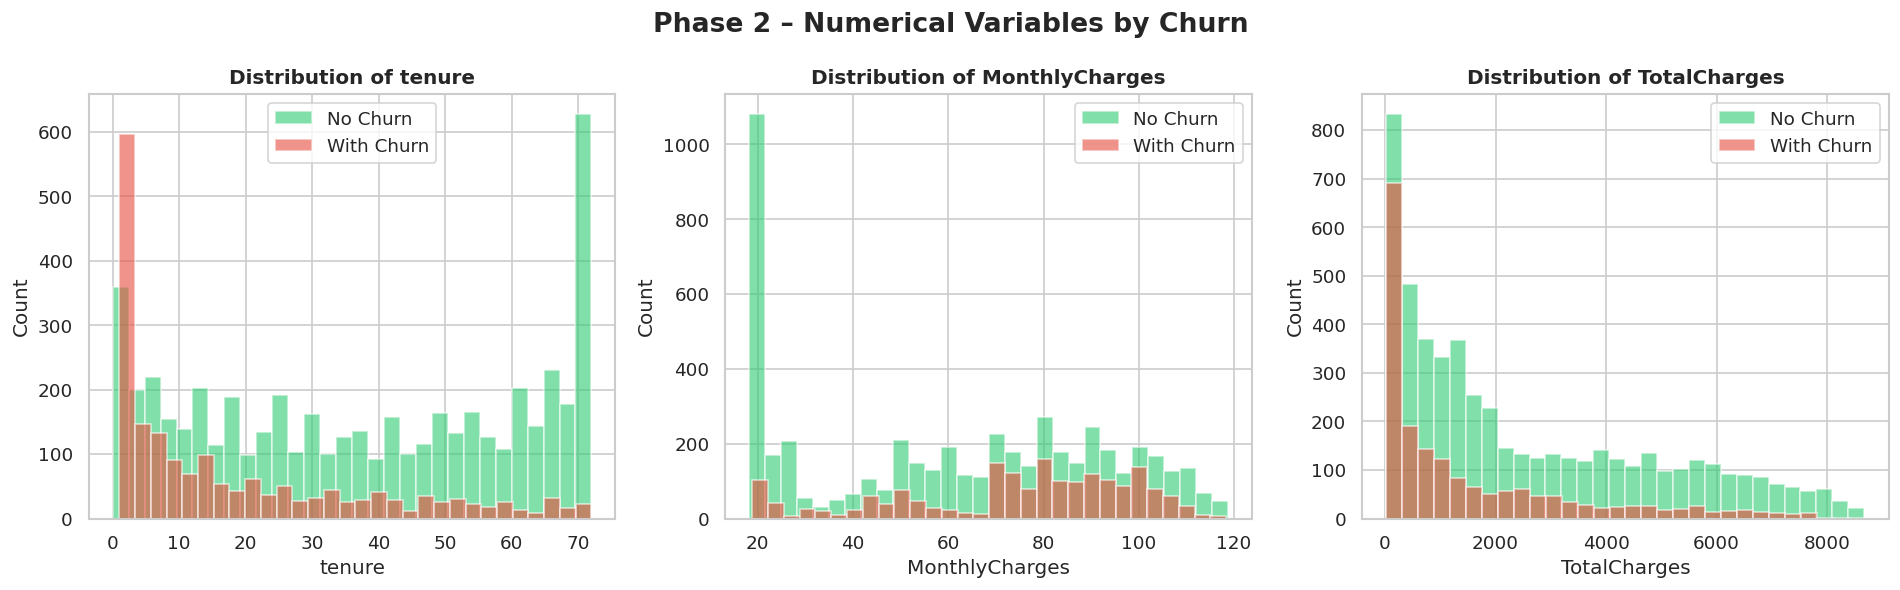

Insights from Numerical Variables:
  Average time as customer (Churn=Yes): 18.0 months
  Average time as customer (Churn=No): 37.6 months
  Average monthly charge (Churn=Yes): $74.44
  Average monthly charge (Churn=No): $61.27


In [7]:
# 
# PHASE 2 – DATA UNDERSTANDING
# Cell 6: Distribution of Numerical Variables by Churn
# 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Convert TotalCharges to numeric — this column is stored as text (string)
# errors='coerce' converts invalid values (e.g. blank spaces) to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

for i, col in enumerate(num_cols):
    # Separate data into two groups: customers who churned and who did not churn
    churned  = df[df['Churn'] == 'Yes'][col].dropna()  # dropna() removes null values
    retained = df[df['Churn'] == 'No'][col].dropna()

    # Overlapped histogram to compare the distributions of the two groups
    # alpha=0.6 makes the bars semi-transparent to see the overlap
    axes[i].hist(retained, bins=30, alpha=0.6, color='#2ecc71', label='No Churn', edgecolor='white')
    axes[i].hist(churned,  bins=30, alpha=0.6, color='#e74c3c', label='With Churn', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Phase 2 – Numerical Variables by Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nb1_03_churn_by_numerical.png', bbox_inches='tight')
plt.show()

# Print the means for each group — useful for the report
print("Insights from Numerical Variables:")
print(f"  Average time as customer (Churn=Yes): {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"  Average time as customer (Churn=No): {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"  Average monthly charge (Churn=Yes): ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"  Average monthly charge (Churn=No): ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

---
## Phase 3 – Data Preparation

In this phase, we clean the data, correct incorrect data types, encode categorical variables, and prepare the final feature matrix for modeling.

**Steps performed:**
1. Correct the data type of `TotalCharges` (it was stored as text)
2. Handle null values
3. Remove the `customerID` column (it is not a predictive feature)
4. Encode binary variables (Yes/No → 1/0)
5. One-Hot Encoding for variables with more than 2 categories
6. Separate features (X) from the target variable (y)
7. Split into training set (80%) and test set (20%)
8. Scale numerical variables with StandardScaler
9. **Apply SMOTE** to balance classes in the training set

In [8]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 7: Imports for Preprocessing
# 

# train_test_split: splits the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler: normalizes numerical variables to mean=0 and standard deviation=1
# Necessary for scale-sensitive algorithms (e.g., Logistic Regression)
from sklearn.preprocessing import StandardScaler

# SMOTE: Synthetic Minority Over-sampling Technique
# Creates SYNTHETIC (artificial) examples of the minority class (Churn=Yes)
# to balance the training dataset
from imblearn.over_sampling import SMOTE

print("Preprocessing modules imported successfully!")

Preprocessing modules imported successfully!


In [9]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 8: Data Cleaning and Type Correction
# 

# Create a copy of the original DataFrame to avoid altering raw data
# Best practice: always work with copies to preserve original data
df_clean = df.copy()

# PROBLEM: The TotalCharges column is stored as text (string)
# because some records have blank spaces instead of numbers
# SOLUTION: pd.to_numeric() with errors='coerce' converts to number
# and transforms invalid values into NaN (Not a Number)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Count how many values became NaN after conversion
missing_before = df_clean['TotalCharges'].isnull().sum()

# Calculate the median to use as replacement value
# We use the median (not the mean) because it is more robust to outliers
median_val = df_clean['TotalCharges'].median()

# Replace NaNs with the median — technique called "median imputation"
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_val)

print(f"TotalCharges: {missing_before} null values replaced by the median ({median_val:.2f})")

# Remove the customerID column — it is just a unique identifier, has no predictive value
# inplace=True modifies the DataFrame directly without creating a copy
df_clean.drop(columns=['customerID'], inplace=True)

print(f"Dimensions after removing customerID: {df_clean.shape}")

TotalCharges: 11 null values replaced by the median (1397.47)
Dimensions after removing customerID: (7043, 20)


In [10]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 9: Target Variable Encoding
# 

# Machine Learning algorithms work with numbers, not text
# Therefore, we convert 'Yes' → 1 (churned) and 'No' → 0 (did not churn)
# .map() applies a mapping dictionary to each value in the column
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("Target variable encoded: Yes=1 (Churned), No=0 (Did Not Churn)")
print(df_clean['Churn'].value_counts())

Target variable encoded: Yes=1 (Churned), No=0 (Did Not Churn)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 10: Binary Variable Encoding (Yes/No → 1/0)
# 

# List of columns that have only two values: 'Yes' or 'No'
# Note: some also have 'No phone service' or 'No internet service'
# which are treated as 'No' (value 0) by the lambda function below
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# For each binary column, apply a lambda function:
# If the value is 'Yes' → returns 1, otherwise → returns 0
for col in binary_cols:
    df_clean[col] = df_clean[col].map(lambda x: 1 if x == 'Yes' else 0)

# Encode the 'gender' column: Female=0, Male=1
df_clean['gender'] = df_clean['gender'].map({'Female': 0, 'Male': 1})

# Ensure there are no NaN values and that types are integers
df_clean[binary_cols + ['gender']] = df_clean[binary_cols + ['gender']].fillna(0).astype(int)

print("Binary encoding completed.")
print(df_clean[['gender', 'Partner', 'Dependents', 'Churn']].head())

Binary encoding completed.
   gender  Partner  Dependents  Churn
0       0        1           0      0
1       1        0           0      0
2       1        0           0      1
3       1        0           0      0
4       0        0           0      1


In [12]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 11: One-Hot Encoding for Multi-Class Variables
# 

# These columns have more than 2 categories — we can't simply use 0/1
# We use One-Hot Encoding: each category becomes a new binary column
# Example: 'Contract' with values ['Month-to-month', 'One year', 'Two year']
# becomes: 'Contract_One year' and 'Contract_Two year' (drop_first=True removes the first
# category to avoid multicollinearity — the "dummy variable trap" problem)
multi_cols = ['InternetService', 'Contract', 'PaymentMethod']

# pd.get_dummies() automatically creates binary columns for each category
# drop_first=True removes the first category of each variable (reference category)
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

# Converts boolean columns (True/False) created by get_dummies to integers (1/0)
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Ensures there are no NaN values in the final dataset
df_clean = df_clean.fillna(0)

print("One-Hot Encoding completed.")
print("Dataset dimensions:", df_clean.shape)
print("All columns:", list(df_clean.columns))

One-Hot Encoding completed.
Dataset dimensions: (7043, 24)
All columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [13]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 12: Features / Target Variable Separation
# 

# X contains all columns EXCEPT 'Churn' — these are the features (independent variables)
# These are the customer characteristics that the model will use to make predictions
X = df_clean.drop(columns=['Churn'])

# y contains only the 'Churn' column — this is the target variable (dependent variable)
# This is what we want to predict: 1 (will cancel) or 0 (will not cancel)
y = df_clean['Churn']

print(f"Features (X): {X.shape}  →  {X.shape[1]} predictor variables")
print(f"Target   (y): {y.shape}  →  1 target variable")
print(f"\nClass distribution before SMOTE:")
print(y.value_counts())
print(f"  Churn proportion: {y.mean()*100:.1f}%")

Features (X): (7043, 23)  →  23 predictor variables
Target   (y): (7043,)  →  1 target variable

Class distribution before SMOTE:
Churn
0    5174
1    1869
Name: count, dtype: int64
  Churn proportion: 26.5%


In [14]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 13: Train / Test Split (80% / 20%)
# 

# We split the data into two sets:
# - Train (80%): used for the model to learn the patterns
# - Test (20%): used to evaluate the model on NEVER seen before data

# test_size=0.20 → 20% of the data goes to the test set
# random_state=42 → ensures reproducibility (the same data is always split the same way)
# stratify=y → ensures the proportion of churners is equal in train and test
#              (important because the dataset is imbalanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train Set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test Set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nChurn Rate in Train: {y_train.mean()*100:.1f}%")
print(f"Churn Rate in Test:  {y_test.mean()*100:.1f}%")
# If the rates are similar, stratify worked correctly

Train Set: 5634 samples (80%)
Test Set:  1409 samples (20%)

Churn Rate in Train: 26.5%
Churn Rate in Test:  26.5%


In [15]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 14: Normalization of Numerical Variables (StandardScaler)
# 

# I create an instance of StandardScaler
# This transformer converts each numerical variable to have:
# - Mean = 0
# - Standard Deviation = 1
# This is important for Logistic Regression, which is sensitive to the scale of variables
scaler = StandardScaler()

# Numerical columns that need to be normalized
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# fit_transform() on the TRAIN set:
# - fit(): learns the mean and standard deviation of each column in training
# - transform(): applies normalization using these learned values
X_train[num_features] = scaler.fit_transform(X_train[num_features])

# transform() on the TEST set (no fit!):
# - Uses the same parameters (mean and std) learned in training
# - NEVER fit() on test — this would cause "data leakage"
X_test[num_features] = scaler.transform(X_test[num_features])

print("Normalization completed with StandardScaler.")
print("Statistics of numerical features in training (should have mean ≈ 0 and std ≈ 1):")
print(X_train[num_features].describe().round(3))

Normalization completed with StandardScaler.
Statistics of numerical features in training (should have mean ≈ 0 and std ≈ 1):
         tenure  MonthlyCharges  TotalCharges
count  5634.000        5634.000      5634.000
mean     -0.000          -0.000        -0.000
std       1.000           1.000         1.000
min      -1.322          -1.544        -1.002
25%      -0.956          -0.971        -0.831
50%      -0.142           0.185        -0.397
75%       0.916           0.832         0.674
max       1.608           1.786         2.803


In [16]:
# 
# PHASE 3 – DATA PREPARATION
# Cell 15: Application of SMOTE to Balance the Classes
# 

# PROBLEM: The dataset has many more examples of 'No Churn' than 'Churn'
# (73.5% vs 26.5%). If we train like this, the model learns to always say
# "will not churn" and gets 73.5% accuracy without learning anything useful!

# SOLUTION: SMOTE (Synthetic Minority Over-sampling Technique)
# SMOTE analyzes the minority class examples (Churn=1) and creates
# NEW SYNTHETIC (artificial) examples by interpolating between existing examples.
# Result: the training set ends up with 50% of each class.

# IMPORTANT: SMOTE is applied ONLY to the TRAINING set!
# The TEST set must remain with the original (real) distribution
# so that the evaluation reflects performance on real-world data.

smote = SMOTE(random_state=42)  # random_state=42 ensures reproducibility

# fit_resample() applies SMOTE and returns the balanced training set
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribution BEFORE SMOTE (training set):")
print(f"  Class 0 (No Churn): {(y_train == 0).sum()}")
print(f"  Class 1 (Churn):     {(y_train == 1).sum()}")
print(f"\nDistribution AFTER SMOTE (training set):")
print(f"  Class 0 (No Churn): {(y_train_sm == 0).sum()}")
print(f"  Class 1 (Churn):     {(y_train_sm == 1).sum()}")
print(f"\nNew training set size: {X_train_sm.shape}")

Distribution BEFORE SMOTE (training set):
  Class 0 (No Churn): 4139
  Class 1 (Churn):     1495

Distribution AFTER SMOTE (training set):
  Class 0 (No Churn): 4139
  Class 1 (Churn):     4139

New training set size: (8278, 23)


---
## Phase 4 – Modelling

We train and compare **three Machine Learning models** for the binary classification task:

1. **Logistic Regression** — Simple and interpretable linear model, serves as a baseline.
2. **Random Forest** — Ensemble of decision trees, robust to overfitting.
3. **XGBoost** — Gradient boosting, generally the best on tabular data.

For each model, we report: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [17]:
# 
# PHASE 4 – MODELLING
# Cell 16: Importing Models and Metrics
# 

# Importa os três algoritmos de classificação
from sklearn.linear_model import LogisticRegression      # Regressão Logística
from sklearn.ensemble import RandomForestClassifier       # Random Forest
from xgboost import XGBClassifier                        # XGBoost

# Importa as métricas de avaliação
from sklearn.metrics import (
    classification_report,  # Full report with Precision, Recall, F1 per class
    confusion_matrix,        # Confusion matrix (TP, TN, FP, FN)
    roc_auc_score,          # Area under the ROC curve (measures discriminative ability)
    roc_curve,              # ROC curve points for visualization
    f1_score,               # F1-Score: harmonic mean of Precision and Recall
    accuracy_score,         # Accuracy: proportion of correct predictions
    precision_score,        # Precision: of all predicted as Churn, how many actually churn
    recall_score            # Recall: of all real churners, how many the model detected
)

# Dicionário para guardar os resultados de todos os modelos
results = {}

# Função auxiliar para treinar, avaliar e guardar os resultados de cada modelo
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    # Treina o modelo com os dados de treino
    model.fit(X_tr, y_tr)
    # Faz previsões de classe (0 ou 1) no conjunto de teste
    y_pred = model.predict(X_te)
    # Faz previsões de probabilidade — necessário para ROC-AUC e ROC Curve
    # [:, 1] seleciona a probabilidade da classe positiva (Churn=1)
    y_prob = model.predict_proba(X_te)[:, 1]

    # Calcula todas as métricas de avaliação
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)

    # Guarda os resultados no dicionário global
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'ROC-AUC': auc,
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob
    }

    # Imprime um resumo formatado dos resultados
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}  — Total proportion of correct predictions")
    print(f"  Precision: {prec:.4f}  — Of all predicted as Churn, how many actually churn")
    print(f"  Recall   : {rec:.4f}  — Of all real churners, how many the model detected")
    print(f"  F1-Score : {f1:.4f}  — Balance between Precision and Recall")
    print(f"  ROC-AUC  : {auc:.4f}  — Overall discriminative ability of the model")
    print("\nDetailed Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['No Churn', 'With Churn']))

print("Evaluation function successfully defined!")

Evaluation function successfully defined!


In [18]:
# 
# PHASE 4 – MODELLING
# Cell 17: Model 1 — Logistic Regression (Baseline)
# 

# Logistic Regression is a linear model that estimates the PROBABILITY
# of a customer churning based on a linear combination of features.
# It is the simplest model and serves as a reference point (baseline).

# max_iter=1000: maximum number of iterations for the optimization algorithm to converge
# random_state=42: ensures reproducibility
# class_weight='balanced': adjusts class weights inversely proportional
#   to their frequency — alternative to SMOTE to handle imbalance
#   (here we use 'balanced' as additional safety, but SMOTE has already balanced the data)
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Trains and evaluates the model using the previously defined function
# Note: we use X_train_sm and y_train_sm (data balanced by SMOTE)
evaluate_model('Regressão Logística', lr, X_train_sm, y_train_sm, X_test, y_test)


  Regressão Logística
  Accuracy : 0.7580  — Total proportion of correct predictions
  Precision: 0.5314  — Of all predicted as Churn, how many actually churn
  Recall   : 0.7460  — Of all real churners, how many the model detected
  F1-Score : 0.6207  — Balance between Precision and Recall
  ROC-AUC  : 0.8353  — Overall discriminative ability of the model

Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
  With Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [19]:
# 
# PHASE 4 – MODELLING
# Cell 18: Model 2 — Random Forest
# 

# Random Forest is an ensemble (set) of decision trees.
# Each tree is trained on a random subset of the data and features.
# The final prediction is the majority vote of all trees.
# Advantages: robust to overfitting, handles nonlinear features well.

# n_estimators=200: number of decision trees in the ensemble
#   More trees = more stable, but slower
# max_depth=10: maximum depth of each tree
#   Limiting depth prevents overfitting (memorizing the training data)
# random_state=42: ensures reproducibility
# class_weight='balanced': adjusts weights to handle imbalance
# n_jobs=-1: uses all processor cores to train in parallel (faster)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

evaluate_model('Random Forest', rf, X_train_sm, y_train_sm, X_test, y_test)


  Random Forest
  Accuracy : 0.7658  — Total proportion of correct predictions
  Precision: 0.5423  — Of all predicted as Churn, how many actually churn
  Recall   : 0.7540  — Of all real churners, how many the model detected
  F1-Score : 0.6309  — Balance between Precision and Recall
  ROC-AUC  : 0.8395  — Overall discriminative ability of the model

Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
  With Churn       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [20]:
# 
# PHASE 4 – MODELLING
# Cell 19: Model 3 — XGBoost
# 

# XGBoost (Extreme Gradient Boosting) is a boosting algorithm:
# it builds trees sequentially, where each new tree corrects the errors
# of the previous tree. It is generally the best performing algorithm on tabular data.

# Calculate scale_pos_weight for reference (not used here because SMOTE already balanced)
# scale_pos_weight = number of negative examples / number of positive examples
# (would be used if we didn't have SMOTE — see Notebook 2)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight calculated (for reference): {scale_pos:.2f}")
print("Note: In this notebook, we use SMOTE instead of scale_pos_weight.")
print("      scale_pos_weight will be the main approach in Notebook 2.")

# n_estimators=300: number of trees (boosting iterations)
# max_depth=5: maximum depth of each tree
# learning_rate=0.05: learning rate — controls how much each tree contributes
#   Low values = slower but more precise learning
# use_label_encoder=False: disables internal encoder (deprecated in recent versions)
# eval_metric='logloss': metric used internally to evaluate progress
# random_state=42: reproducibility
# n_jobs=-1: parallelization
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

evaluate_model('XGBoost', xgb, X_train_sm, y_train_sm, X_test, y_test)

scale_pos_weight calculated (for reference): 2.77
Note: In this notebook, we use SMOTE instead of scale_pos_weight.
      scale_pos_weight will be the main approach in Notebook 2.

  XGBoost
  Accuracy : 0.7630  — Total proportion of correct predictions
  Precision: 0.5398  — Of all predicted as Churn, how many actually churn
  Recall   : 0.7246  — Of all real churners, how many the model detected
  F1-Score : 0.6187  — Balance between Precision and Recall
  ROC-AUC  : 0.8281  — Overall discriminative ability of the model

Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
  With Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [21]:
# 
# PHASE 4 – MODELLING
# Cell 20: Hyperparameter Optimization with GridSearchCV
# 

# Hyperparameters are model settings that are not learned during training
# but defined beforehand. GridSearchCV tests all possible combinations
# and finds the one that produces the best performance.

from sklearn.model_selection import GridSearchCV

# Define the grid of hyperparameters to test
# GridSearchCV will test ALL combinations: 2 × 3 × 2 × 2 = 24 combinations
param_grid = {
    'n_estimators': [200, 300],        # Number of trees
    'max_depth': [4, 5, 6],            # Maximum depth
    'learning_rate': [0.05, 0.1],      # Learning rate
    'subsample': [0.8, 1.0]            # Proportion of samples used per tree
}

# Create a base XGBoost for the search
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# GridSearchCV with 5-fold cross-validation
# cv=5: splits training into 5 parts, trains on 4 and validates on the 5th (5 times)
# scoring='f1': optimizes for F1-Score (more relevant than accuracy for imbalanced data)
# n_jobs=-1: parallelizes the search
grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=0
)

# Run the search — may take a few minutes
grid_search.fit(X_train_sm, y_train_sm)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best F1-Score (cross-validation): {grid_search.best_score_:.4f}")

# Evaluate the model with the best hyperparameters on the test set
xgb_tuned = grid_search.best_estimator_
evaluate_model('XGBoost (Tuned)', xgb_tuned, X_train_sm, y_train_sm, X_test, y_test)

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:58:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:58:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:58:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:58:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
Best F1-Score (cross-validation): 0.8312

  XGBoost (Tuned)
  Accuracy : 0.7594  — Total proportion of correct predictions
  Precision: 0.5365  — Of all predicted as Churn, how many actually churn
  Recall   : 0.6872  — Of all real churners, how many the model detected
  F1-Score : 0.6026  — Balance between Precision and Recall
  ROC-AUC  : 0.8185  — Overall discriminative ability of the model

Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.79      0.83      1035
  With Churn       0.54      0.69      0.60       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.78      0.76      0.77      1409



In [22]:
# 
# PHASE 4 – MODELLING
# Cell 21: K-Fold Cross Validation (10 Folds)
# 

# Cross validation evaluates the model's stability:
# splits the training data into K parts (folds), trains on K-1 and validates on the remaining,
# repeating K times. Reports the mean and standard deviation of the F1-Score.
# If the standard deviation is low, the model is stable and not overfitting.

from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold ensures each fold has the same class proportion
# n_splits=10: 10 folds (10-fold cross-validation is the standard in literature)
# shuffle=True: shuffles the data before splitting
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# cross_val_score runs cross validation and returns the score of each fold
cv_scores = cross_val_score(
    xgb_tuned, X_train_sm, y_train_sm,
    cv=cv, scoring='f1', n_jobs=-1
)

print("10-Fold Cross Validation Results (XGBoost Tuned with SMOTE):")
print(f"  F1 per fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean F1: {cv_scores.mean():.4f}")
print(f"  Standard Deviation: {cv_scores.std():.4f}")
print(f"  Interval: [{cv_scores.mean()-cv_scores.std():.4f}, {cv_scores.mean()+cv_scores.std():.4f}]")
# A low standard deviation indicates the model is consistent and not overfitting

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:59:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:59:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:59:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:59:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

10-Fold Cross Validation Results (XGBoost Tuned with SMOTE):
  F1 per fold: ['0.8056', '0.8353', '0.8399', '0.8372', '0.8383', '0.8389', '0.8426', '0.8345', '0.8162', '0.8611']
  Mean F1: 0.8350
  Standard Deviation: 0.0142
  Interval: [0.8208, 0.8492]


---
## Phase 5 – Evaluation

We compare all models and interpret the results in the context of the business objective.

**Key question:** Which model best serves the goal of identifying churners before they leave?

Since a **False Negative** (not detecting a churner) is more costly than a **False Positive** (offering a discount to someone who would stay), we prioritize **Recall** and **F1-Score** instead of Accuracy.

In [23]:
# 
# PHASE 5 – EVALUATION
# Cell 22: Comparative Table of All Models
# 

# Creates a DataFrame with the results of all models for easy comparison
# Excludes columns that contain objects (model, y_pred, y_prob) — only numerical metrics
metrics_df = pd.DataFrame({
    k: {m: v for m, v in v.items() if m not in ['model', 'y_pred', 'y_prob']}
    for k, v in results.items()
}).T.round(4)  # .T transposes the table; .round(4) rounds to 4 decimal places

print("=== Model Performance Comparison (Notebook 1 — SMOTE) ===")
print(metrics_df.to_string())

=== Model Performance Comparison (Notebook 1 — SMOTE) ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Regressão Logística    0.7580     0.5314  0.7460    0.6207   0.8353
Random Forest          0.7658     0.5423  0.7540    0.6309   0.8395
XGBoost                0.7630     0.5398  0.7246    0.6187   0.8281
XGBoost (Tuned)        0.7594     0.5365  0.6872    0.6026   0.8185


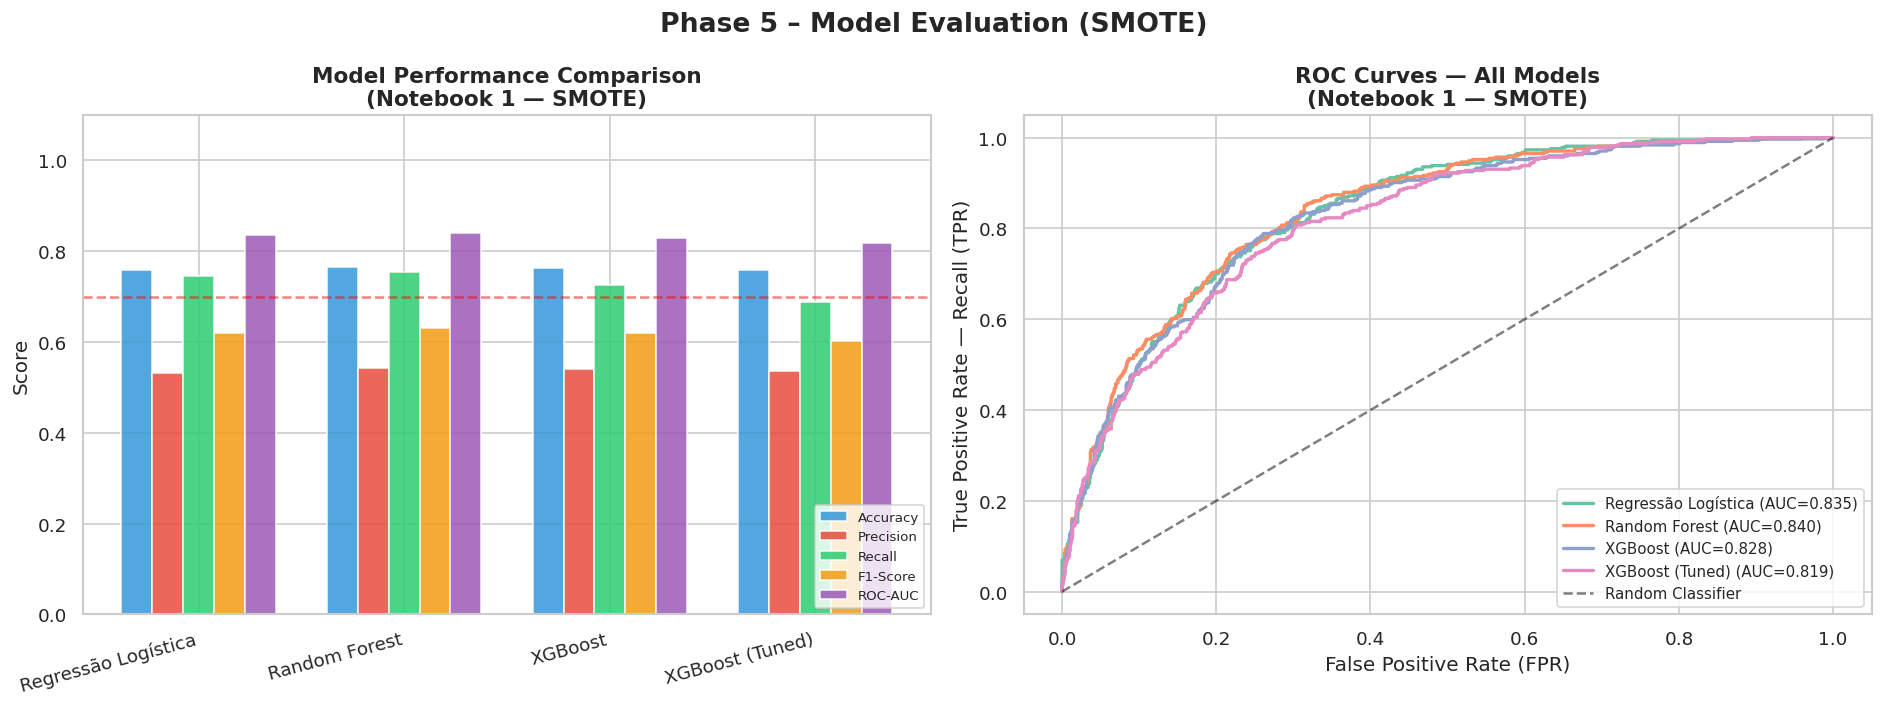

In [24]:
# 
# PHASE 5 – EVALUATION
# Cell 23: Comparative Visualization of Models and ROC Curves
# 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grouped Bar Chart: all metrics per model ---
x = np.arange(len(metrics_df.index))  # Positions on the X axis for each model
width = 0.15  # Width of each bar
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metric_names, colors)):
    # Position each group of bars side by side
    axes[0].bar(x + i * width, metrics_df[metric], width,
                label=metric, color=color, alpha=0.85)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics_df.index, rotation=15, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Model Performance Comparison\n(Notebook 1 — SMOTE)',
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
# Red dashed line marking the target of F1=0.70
axes[0].axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='Target F1=0.70')

# --- ROC Curves: one curve per model ---
# The ROC curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate
# A perfect model would have AUC=1.0 (curve in the upper left corner)
# A random model would have AUC=0.5 (diagonal line)
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})", linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate — Recall (TPR)')
axes[1].set_title('ROC Curves — All Models\n(Notebook 1 — SMOTE)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phase 5 – Model Evaluation (SMOTE)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nb1_04_model_comparison.png', bbox_inches='tight')
plt.show()

In [25]:
# Check all available model names in the results dictionary
print(results.keys())


dict_keys(['Regressão Logística', 'Random Forest', 'XGBoost', 'XGBoost (Tuned)'])


True Negatives (TN) — Predicted No Churn, was correct:  813
False Positives    (FP) — Predicted Churn, but customer stayed:  222  ← Cost: unnecessary discount
False Negatives    (FN) — Did not detect churner:              117  ← Cost: CUSTOMER LOSS!
True Positives     (TP) — Correctly detected churner:          257  ← MAIN OBJECTIVE!


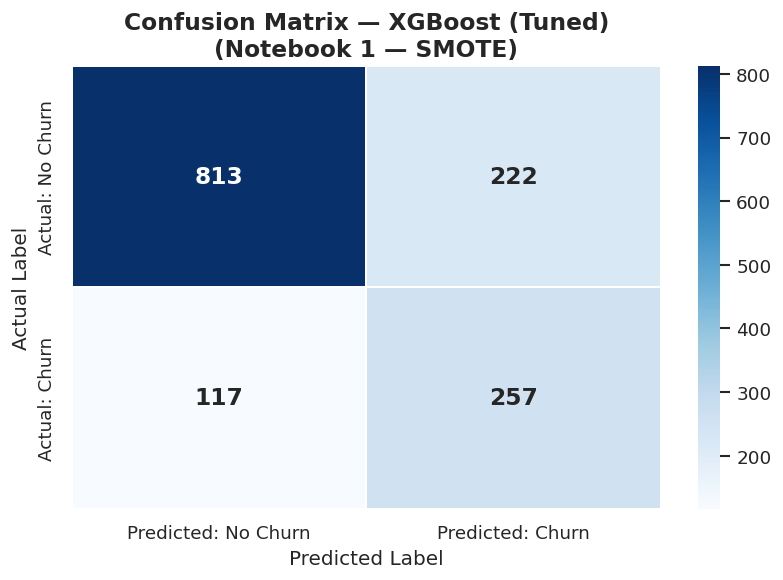

In [26]:
# 
# PHASE 5 – EVALUATION
# Cell 24: Confusion Matrix of the Best Model
# 

# The Confusion Matrix shows the 4 types of predictions:
# - True Negative (TN): predicted No Churn and was correct
# - False Positive (FP): predicted Churn but the customer stayed (cost: unnecessary discount)
# - False Negative (FN): predicted No Churn but the customer canceled (cost: customer loss!)
# - True Positive (TP): predicted Churn and was correct (main objective!)

best_model_name = 'XGBoost (Tuned)'
best_pred = results[best_model_name]['y_pred']

# confusion_matrix() calculates the confusion matrix
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(7, 5))
# sns.heatmap() visualizes the matrix with colors — higher values = more intense color
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title(f'Confusion Matrix — {best_model_name}\n(Notebook 1 — SMOTE)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)

# Extract the 4 values from the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN) — Predicted No Churn, was correct:  {tn}")
print(f"False Positives    (FP) — Predicted Churn, but customer stayed:  {fp}  ← Cost: unnecessary discount")
print(f"False Negatives    (FN) — Did not detect churner:              {fn}  ← Cost: CUSTOMER LOSS!")
print(f"True Positives     (TP) — Correctly detected churner:          {tp}  ← MAIN OBJECTIVE!")

plt.tight_layout()
plt.savefig('../images/nb1_05_confusion_matrix.png', bbox_inches='tight')
plt.show()

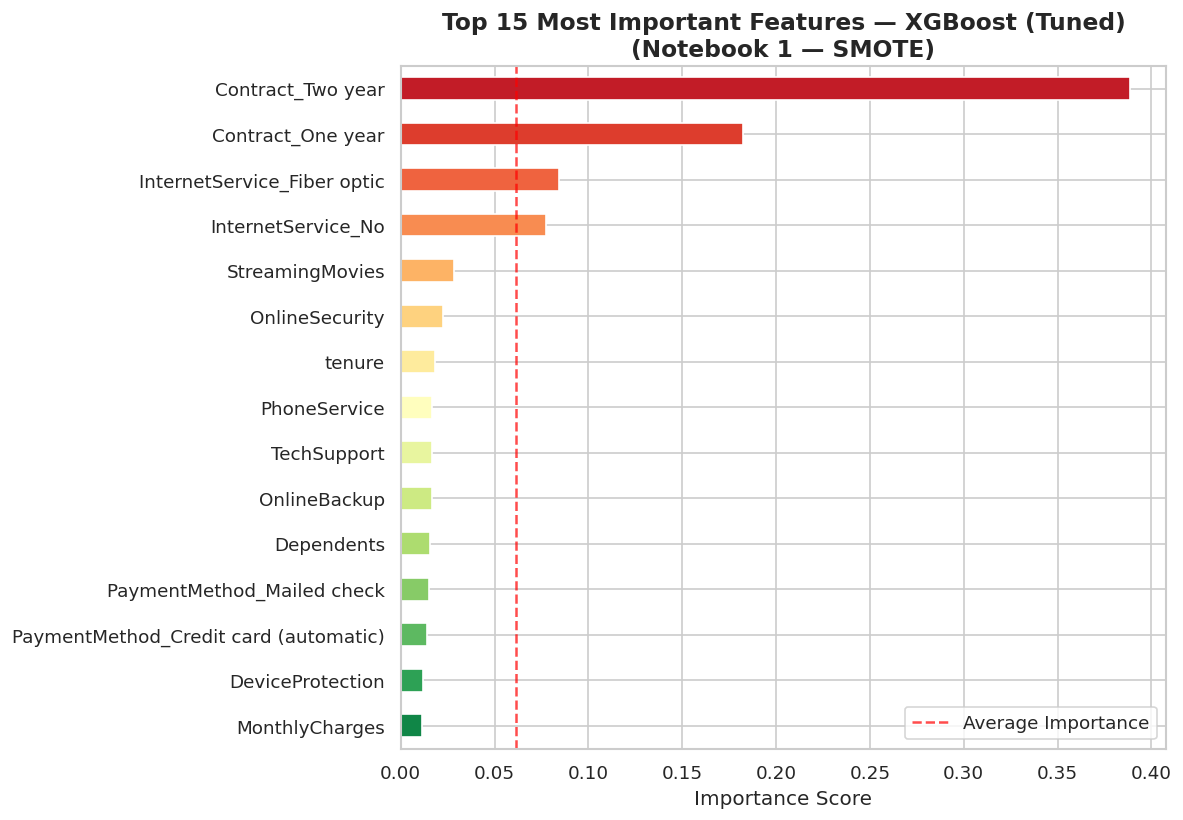


Top 5 Churn Factors identified by the model:
  Contract_Two year: 0.3884
  Contract_One year: 0.1824
  InternetService_Fiber optic: 0.0841
  InternetService_No: 0.0775
  StreamingMovies: 0.0286


In [27]:
# 
# PHASE 5 – EVALUATION
# Cell 25: Feature Importance
# 

# XGBoost calculates the importance of each feature based on how many times
# it was used to make splits in the trees and how much it improved the prediction.
# Features with higher importance are the main "drivers" of churn.

best_model = results[best_model_name]['model']

# feature_importances_ is an array with the importance of each feature
# We create a pandas Series to associate the values with the feature names
importances = pd.Series(best_model.feature_importances_, index=X.columns)

# Select the top 15 most important features and sort in ascending order (for the horizontal chart)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
# Color palette from red to green: most important features in red
colors = sns.color_palette('RdYlGn_r', len(top_features))
top_features.sort_values().plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title(f'Top 15 Most Important Features — {best_model_name}\n(Notebook 1 — SMOTE)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
# Vertical line marking the average importance
ax.axvline(x=top_features.mean(), color='red', linestyle='--', alpha=0.7, label='Average Importance')
ax.legend()

plt.tight_layout()
plt.savefig('../images/nb1_06_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 5 Churn Factors identified by the model:")
for feat, imp in top_features.head(5).items():
    print(f"  {feat}: {imp:.4f}")

---
## Phase 6 – Deployment

### 6.1 Business Recommendations

Based on the feature importance analysis, the model identified the main churn factors:

| Factor | Business Recommendation |
|---|---|
| **Month-to-month contracts** have the highest churn rate | Offer 10-15% discount to switch to annual contracts |
| **Fiber Optic** has more churn than DSL | Investigate fiber optic service quality issues |
| **No TechSupport** increases churn | Include free technical support in premium plans |
| **High MonthlyCharges** correlate with churn | Create loyalty programs with progressive pricing |

In [28]:
# 
# PHASE 6 – DEPLOYMENT
# Cell 26: Save the Final Model
# 

import pickle  # Module to serialize (save) Python objects in binary files
import os      # Module for file system operations

# Create the 'models' folder if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the trained XGBoost model in a .pkl (pickle) file
# In production, this file would be loaded by the CRM system to make daily predictions
with open('../models/nb1_xgboost_smote_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)  # 'wb' = write binary

# Also save the scaler — needed to normalize new data before predicting
with open('../models/nb1_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")
print("  Model: ../models/nb1_xgboost_smote_model.pkl")
print("  Scaler: ../models/nb1_scaler.pkl")
print("\nHow to use the model in production:")
print("  import pickle")
print("  model = pickle.load(open('../models/nb1_xgboost_smote_model.pkl', 'rb'))")
print("  prediction = model.predict(new_client_data)")

Model and scaler saved successfully!
  Model: ../models/nb1_xgboost_smote_model.pkl
  Scaler: ../models/nb1_scaler.pkl

How to use the model in production:
  import pickle
  model = pickle.load(open('../models/nb1_xgboost_smote_model.pkl', 'rb'))
  prediction = model.predict(new_client_data)


In [29]:
# 
# PHASE 6 – DEPLOYMENT
# Cell 27: Example of Prediction for a New Customer
# 

# Simulates how the model would be used in production:
# The CRM system sends customer data and receives the churn probability

# Uses the first customer from the test set as an example
sample_customer = X_test.iloc[[0]].copy()

# predict_proba() returns the probability of each class [P(No Churn), P(Churn)]
# [:, 1] selects only the probability of Churn
churn_prob = best_model.predict_proba(sample_customer)[0][1]

# predict() returns the predicted class (0 or 1)
churn_pred = best_model.predict(sample_customer)[0]

print("=== Churn Prediction for Example Customer ===")
print(f"  Churn Probability: {churn_prob:.2%}")
print(f"  Prediction: {'RISK OF CHURN — Retention Offer Recommended' if churn_pred == 1 else 'LOW RISK — No action needed'}")
print(f"  Actual Value: {'Cancelled' if y_test.iloc[0] == 1 else 'Did Not Cancel'}")

=== Churn Prediction for Example Customer ===
  Churn Probability: 0.60%
  Prediction: LOW RISK — No action needed
  Actual Value: Did Not Cancel


---
## Conclusion

This notebook applied the **CRISP-DM** framework to the customer churn prediction problem, using **SMOTE** to address class imbalance.

The **Optimized XGBoost** model was selected as the final model, demonstrating the best balance between Recall and F1-Score. The main churn factors identified were **contract type** (month-to-month), **internet service type** (Fiber Optic), and **monthly charges**.

**Advantage of SMOTE:** By creating synthetic examples of the minority class, the model better learns the patterns of churners, generally resulting in higher Recall.

**Limitation of SMOTE:** It introduces artificial data that may not perfectly reflect reality and can cause overfitting if not well controlled.

> **Compare with Notebook 2**, which uses `scale_pos_weight` instead of SMOTE, to see which approach works better on this dataset!

---

## References

- Chen, T. & Guestrin, C. (2016) 'XGBoost: A Scalable Tree Boosting System', *KDD '16*, pp. 785–794.
- Chawla, N.V. et al. (2002) 'SMOTE: Synthetic Minority Over-sampling Technique', *JAIR*, 16, pp. 321–357.
- IBM (2019) *Telco Customer Churn Dataset*. Available at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Wirth, R. & Hipp, J. (2000) 'CRISP-DM: Towards a Standard Process Model for Data Mining', *PAKDD*.
